# Notebook 01 — Data Exploration

**Mục tiêu notebook này:**
- Làm quen với dataset được dùng trong toàn project
- Hiểu các khái niệm thống kê cơ bản xuất hiện trong quá trình khám phá dữ liệu
- Chuẩn bị nền tảng để hiểu tại sao bias có thể xuất hiện từ chính dữ liệu

---
## 0. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

from src import (
    load_dataset,
    preprocess,
    set_style,
    plot_class_distribution,
    plot_correlation_heatmap,
)

set_style()
RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


## 1. Load Dataset

### Khái niệm: Synthetic Data

**Synthetic data** (dữ liệu tổng hợp) là dữ liệu được tạo ra bằng **mô hình toán học hoặc thuật toán sinh dữ liệu**, thay vì thu thập từ thế giới thực.

Trong notebook này, ta sử dụng hàm:

```python
sklearn.datasets.make_classification
```

để tạo một **binary classification dataset**.

Hàm này sinh dữ liệu với các tham số chính:

- **n_samples** — số lượng điểm dữ liệu
- **n_features** — tổng số features
- **n_informative** — số features thực sự chứa thông tin dự đoán
- **n_redundant** — số features là tổ hợp tuyến tính của informative features
- phần còn lại là **noise features**

Về mặt khái niệm, dataset được sinh theo một hàm phân loại ẩn:

$$
y = f(x_1, x_2, ..., x_k) + \epsilon
$$

trong đó:

- $x_1,...,x_k$ là **informative features**
- $\epsilon$ là **noise ngẫu nhiên**

Synthetic data rất hữu ích trong nghiên cứu vì ta có thể **kiểm soát hoàn toàn cấu trúc dữ liệu**.

---

### Khái niệm: Ground Truth

**Ground truth** là nhãn đúng thực sự của dữ liệu.

Trong dữ liệu thực tế, ground truth thường đến từ:

- nhãn do con người gán
- kết quả quan sát được

Ví dụ:

- bệnh / không bệnh
- fraud / non-fraud

Trong **synthetic data**, ground truth được tạo trực tiếp từ quá trình sinh dữ liệu.

Điều này cho phép ta biết chính xác:

- feature nào thực sự quan trọng
- feature nào chỉ là noise
- cấu trúc thực của dữ liệu

Nhờ đó ta có thể kiểm tra liệu model có học đúng **pattern thật** hay chỉ đang học **noise**.

---

### Khái niệm: Signal vs Noise

Trong phân tích dữ liệu, thông tin thường được chia thành hai phần:

**Signal**

Là phần dữ liệu thực sự chứa thông tin dự đoán.

$$
Signal = \{x_1, x_2, ..., x_k\}
$$

Đây là các **informative features** giúp model học được quy luật của dữ liệu.

---

**Noise**

Noise là phần biến động ngẫu nhiên không liên quan đến target.

$$
y = f(x) + \epsilon
$$

trong đó:

- $f(x)$ là **signal**
- $\epsilon$ là **noise**

Noise có thể đến từ:

- sai số đo lường
- biến thiên ngẫu nhiên
- features không liên quan

Nếu dataset chứa quá nhiều noise, model có thể:

- học sai pattern
- **overfit vào dữ liệu ngẫu nhiên**

Synthetic dataset cho phép kiểm soát **signal-to-noise ratio**, giúp đánh giá độ robust của model.

---

### Khái niệm: Redundant Features

`n_redundant` features là các feature được tạo bằng **tổ hợp tuyến tính của informative features**.

Ví dụ:

$$
x_3 = 2x_1 + 0.5x_2
$$

Feature $x_3$ không mang thông tin mới, nhưng vẫn tương quan mạnh với target.

Điều này mô phỏng hiện tượng phổ biến trong dữ liệu thực: **nhiều biến có mối quan hệ tuyến tính với nhau**.

---

### Khái niệm: Multicollinearity

**Multicollinearity** xảy ra khi nhiều features có tương quan cao với nhau.

Giả sử:

$$
x_2 \approx a x_1 + b
$$

khi đó $x_1$ và $x_2$ gần như chứa cùng một thông tin.

Hệ quả:

- model khó xác định **feature nào thực sự quan trọng**
- hệ số trong mô hình tuyến tính trở nên **không ổn định**
- việc **interpret model** trở nên khó khăn

Synthetic dataset có thể mô phỏng hiện tượng này thông qua `n_redundant`.

---

### Khái niệm: Class Imbalance

**Class imbalance** xảy ra khi số lượng mẫu giữa các class không cân bằng.

Ví dụ:

- 80% class 0
- 20% class 1

Tỉ lệ imbalance là:

$$
ratio = \frac{N_{majority}}{N_{minority}}
$$

Trong ví dụ trên:

$$
ratio = \frac{80}{20} = 4:1
$$

Class imbalance rất quan trọng vì:

- model thường **thiên về majority class**
- minority class khó được học đúng
- có thể dẫn đến **bias trong model**

Trong nhiều hệ thống thực tế (fraud detection, medical diagnosis), class imbalance là hiện tượng rất phổ biến.

In [2]:
bundle = load_dataset(
    'synthetic_clf',
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    class_imbalance=0.35,
    random_state=RANDOM_STATE,
)

print(bundle)
print('\nMetadata:')
for k, v in bundle.meta.items():
    print(f'  {k}: {v}')

DataBundle(rows=3000, features=20, source='synthetic_classification')

Metadata:
  source: synthetic_classification
  n_samples: 3000
  n_features: 20
  n_informative: 8
  class_imbalance: 0.35
  class_distribution: {0: 1919, 1: 1081}
  random_state: 42


**Dataset Summary**

Dataset gồm **3000 mẫu** với **20 features**, trong đó **8 features là informative**, phần còn lại là **redundant hoặc noise**. Điều này giúp mô phỏng dữ liệu thực tế, nơi không phải mọi feature đều mang thông tin dự đoán.

Phân bố lớp cho thấy **class imbalance nhẹ**:

- Class 0: **1919 mẫu (~64%)**
- Class 1: **1081 mẫu (~36%)**

Tỷ lệ mất cân bằng khoảng:

$
\text{Imbalance Ratio} \approx \frac{1919}{1081} \approx 1.8:1
$

Mức imbalance này đủ để quan sát khả năng **model thiên về majority class**, nhưng chưa quá cực đoan, do đó vẫn phù hợp cho việc phân tích các dạng **bias phát sinh từ dữ liệu**.

---
## 2. Khám phá cấu trúc dữ liệu

### Khái niệm: Feature Matrix ($X$) và Target Vector ($y$)

Trong **supervised learning**, dataset thường được biểu diễn dưới dạng hai thành phần:

| Ký hiệu | Tên | Ý nghĩa |
|---|---|---|
| $X$ | Feature matrix | Ma trận đầu vào, shape = $(n_{samples}, n_{features})$ |
| $y$ | Target vector | Vector nhãn, shape = $(n_{samples},)$ |

Mỗi hàng của $X$ đại diện cho một **observation (mẫu dữ liệu)**, còn mỗi cột là một **feature (đặc trưng)** mô tả mẫu đó.

Ví dụ cấu trúc của feature matrix:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \dots & x_{1p} \\
x_{21} & x_{22} & \dots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{np}
\end{bmatrix}
$$

trong đó:

- $n$ là số **samples**
- $p$ là số **features**

Target vector tương ứng:

$$
y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

Trong supervised learning, model sẽ học một hàm ánh xạ:

$$
y = f(X)
$$

để dự đoán nhãn từ các features.

---

### Khái niệm: Descriptive Statistics

Trước khi huấn luyện model, ta cần phân tích **thống kê mô tả (descriptive statistics)** để hiểu cấu trúc dữ liệu.

Các yếu tố thường được kiểm tra:

**1. Missing Values**

Giá trị bị thiếu trong dataset.

Nếu tồn tại:

- model có thể không train được
- cần xử lý bằng **imputation** hoặc **loại bỏ dữ liệu**

---

**2. Outliers**

Outliers là các giá trị cực đoan nằm xa phần lớn dữ liệu.

Ví dụ định nghĩa phổ biến dựa trên **z-score**:

$$
z = \frac{x - \mu}{\sigma}
$$

trong đó:

- $\mu$ là mean
- $\sigma$ là standard deviation

Thông thường:

$$
|z| > 3
$$

được xem là outlier.

Outliers có thể:

- là **noise**
- hoặc là **signal quan trọng**

---

**3. Scale Differences**

Các features có thể nằm ở các thang đo rất khác nhau.

Ví dụ:

| Feature | Range |
|---|---|
| Age | 0 – 100 |
| Income | 0 – 1,000,000 |

Sự khác biệt scale có thể làm model (đặc biệt là **distance-based models**) bị lệch.

Một cách chuẩn hóa phổ biến là **standardization**:

$$
x' = \frac{x - \mu}{\sigma}
$$

---

**4. Skewness**

Skewness mô tả **độ lệch của phân phối dữ liệu**.

Nếu phân phối lệch phải:

$$
skewness > 0
$$

Nếu lệch trái:

$$
skewness < 0
$$

Skewed distributions có thể ảnh hưởng đến:

- linear models
- statistical tests

Do đó đôi khi cần các phép biến đổi như:

$$
x' = \log(x)
$$

để làm phân phối gần **normal distribution** hơn.

In [3]:
X, y = bundle.X, bundle.y

print('=== Shape ===')
print(f'X: {X.shape}  |  y: {y.shape}')

print('\n=== First 5 rows ===')
display(X.head())

print('\n=== Descriptive Statistics ===')
display(X.describe().round(3))

=== Shape ===
X: (3000, 20)  |  y: (3000,)

=== First 5 rows ===


,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
0,-0.260358,-1.445632,-1.562941,-0.891062,0.133209,0.425651,-1.180891,-0.559656,-0.846491,-0.462484,0.578965,-1.269498,-0.380709,0.690286,0.560022,0.180109,-0.360963,-1.560401,1.181779,1.818828
1,3.020772,-0.823403,-1.409555,4.087151,0.439988,4.769986,0.340565,-1.832294,0.725910,-0.457687,2.631727,-6.564530,-6.519729,-0.877786,-1.511150,0.061045,-1.083437,2.504038,-0.150949,0.053802
2,-1.969909,1.474204,-1.069965,1.184392,0.472848,0.450954,-0.226709,-0.777936,-1.557371,0.669488,2.080391,-2.019504,-0.119385,1.409334,0.752481,0.122248,0.180407,0.700234,1.506348,0.377303
3,-2.534083,-0.313677,-0.743241,1.300895,-0.005133,-1.192537,0.405288,0.250572,1.011256,-0.466834,-0.101198,-1.477486,-0.432156,0.001199,-0.070415,-0.223281,-1.237905,-1.874948,0.497620,4.197759
4,-3.363608,-0.015882,-1.223582,0.422220,-0.722078,-1.076812,0.748798,1.186107,0.466314,-0.359251,1.570054,-2.671312,1.594067,0.601829,0.938861,-0.147431,-0.984523,1.464194,0.637681,2.178579



=== Descriptive Statistics ===


,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,0.005,0.024,-0.327,0.675,-0.331,1.353,-0.023,-0.963,-0.010,-0.004,1.008,-1.842,-1.337,-0.002,-0.200,0.013,-0.025,0.007,0.024,0.331
std,1.900,1.020,1.787,1.892,1.759,2.668,1.011,1.672,1.002,1.013,1.619,2.501,3.110,1.006,1.837,0.995,1.000,2.092,0.989,1.903
min,-7.528,-3.637,-6.364,-5.982,-7.114,-9.843,-3.543,-6.543,-3.550,-3.781,-4.628,-11.285,-12.835,-3.426,-9.425,-3.307,-3.332,-7.920,-3.152,-7.019
25%,-1.266,-0.656,-1.494,-0.605,-1.528,-0.432,-0.691,-2.026,-0.686,-0.689,-0.084,-3.433,-3.121,-0.663,-1.336,-0.663,-0.680,-1.464,-0.645,-0.903
50%,-0.009,0.019,-0.390,0.711,-0.243,1.366,0.002,-0.968,0.002,0.026,0.957,-1.787,-1.287,-0.017,-0.128,-0.001,-0.035,0.057,0.032,0.378
75%,1.284,0.717,0.851,1.975,0.896,3.084,0.671,0.139,0.671,0.677,2.059,-0.254,0.491,0.657,0.999,0.688,0.639,1.465,0.684,1.659
max,7.020,3.542,5.421,9.681,5.879,12.653,3.343,7.370,2.992,3.368,7.686,6.463,10.867,3.809,8.161,3.574,3.451,7.330,3.512,7.086


### Kết quả kiểm tra dữ liệu

#### Dataset Shape

Feature matrix và target vector có kích thước:

- $X$ shape: $(3000, 20)$
- $y$ shape: $(3000,)$

Điều này nghĩa là:

- **3000 samples**
- **20 features**

---

#### First Observations

Một vài hàng đầu tiên của dataset cho thấy:

- Tất cả features đều là **giá trị số liên tục**
- Các giá trị đã được **centered quanh 0** và có độ phân tán tương đối đồng đều

Điều này phù hợp với cách `make_classification` sinh dữ liệu, thường sử dụng phân phối gần **Gaussian**.

---

#### Descriptive Statistics

Thống kê mô tả cho thấy:

- **count = 3000** cho mọi feature → dataset đầy đủ
- **mean gần 0** cho nhiều features → dữ liệu đã được chuẩn hóa phần nào
- **standard deviation khác nhau giữa các features** → scale chưa hoàn toàn đồng nhất
- tồn tại các **giá trị cực trị (min / max)** khá lớn → có thể xem như outliers

In [4]:
print('=== Missing Values ===')
missing = X.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

print('\n=== Data Types ===')
print(X.dtypes.value_counts())

=== Missing Values ===
No missing values.

=== Data Types ===
float64    20
Name: count, dtype: int64


#### Missing Values

Kiểm tra missing values:

```
No missing values
```

Điều này có nghĩa dataset **không cần bước xử lý imputation**.

---

#### Data Types

Tất cả features đều có kiểu dữ liệu:

```
float64
```

Điều này cho thấy:

- dataset hoàn toàn **numerical**
- phù hợp cho hầu hết các thuật toán machine learning
- **không cần encoding categorical variables**

---
## 3. Phân tích Target Variable

### Khái niệm: Class Distribution

**Class distribution** là tỉ lệ phân bố của các nhãn trong **target vector $y$**.

Trong bài toán **binary classification**, target chỉ có hai giá trị:

- **Class 0** — negative class
- **Class 1** — positive class

Phân bố lớp được tính bằng số lượng mẫu thuộc mỗi class:

$$
N_c = \sum_{i=1}^{n} \mathbf{1}(y_i = c)
$$

trong đó:

- $N_c$ là số mẫu thuộc class $c$
- $\mathbf{1}(\cdot)$ là **indicator function**

---

### Balanced vs Imbalanced Dataset

Một dataset có thể:

**Balanced**

$$
P(y=0) \approx P(y=1)
$$

Ví dụ:

| Class | Count |
|------|------|
| 0 | 1500 |
| 1 | 1500 |

---

**Imbalanced**

$$
P(y=0) \neq P(y=1)
$$

Ví dụ:

| Class | Count |
|------|------|
| 0 | 2400 |
| 1 | 600 |

---

### Imbalance Ratio

Mức độ mất cân bằng được đo bằng **imbalance ratio**:

$$
\text{Imbalance Ratio} =
\frac{N_{\text{majority}}}{N_{\text{minority}}}
$$

Trong dataset hiện tại:

- $N_0 = 1919$
- $N_1 = 1081$

$$
\text{Imbalance Ratio} \approx
\frac{1919}{1081} \approx 1.78
$$

Điều này cho thấy dataset có **mức mất cân bằng nhẹ**.

---

### Tại sao Class Imbalance quan trọng?

Khi imbalance lớn (ví dụ $> 3:1$), các metrics như **accuracy** trở nên không đáng tin cậy.

Ví dụ:

Dataset có:

- 95% class 0
- 5% class 1

Một model luôn dự đoán:

$$
\hat{y} = 0
$$

vẫn đạt:

$$
Accuracy = 95\%
$$

nhưng **model không học được gì về class 1**.

Do đó trong dataset imbalanced cần dùng các metrics khác như:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**

---

### Liên hệ với Bias

Trong thực tế, **survivorship bias** thường làm **tăng class imbalance**.

Ví dụ:

- dataset chỉ chứa **công ty còn tồn tại**
- các công ty phá sản bị loại bỏ

Khi đó:

$$
N_{\text{success}} \gg N_{\text{failure}}
$$

Model sẽ học chủ yếu từ **survivors**, dẫn đến **kết luận sai lệch về xác suất thành công**.

In [5]:
print('=== Target Distribution ===')
print(y.value_counts())
print(f'\nClass ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1')
print(f'Minority class proportion: {y.mean():.1%}')

=== Target Distribution ===
target
0    1919
1    1081
Name: count, dtype: int64

Class ratio: 1.78:1
Minority class proportion: 36.0%


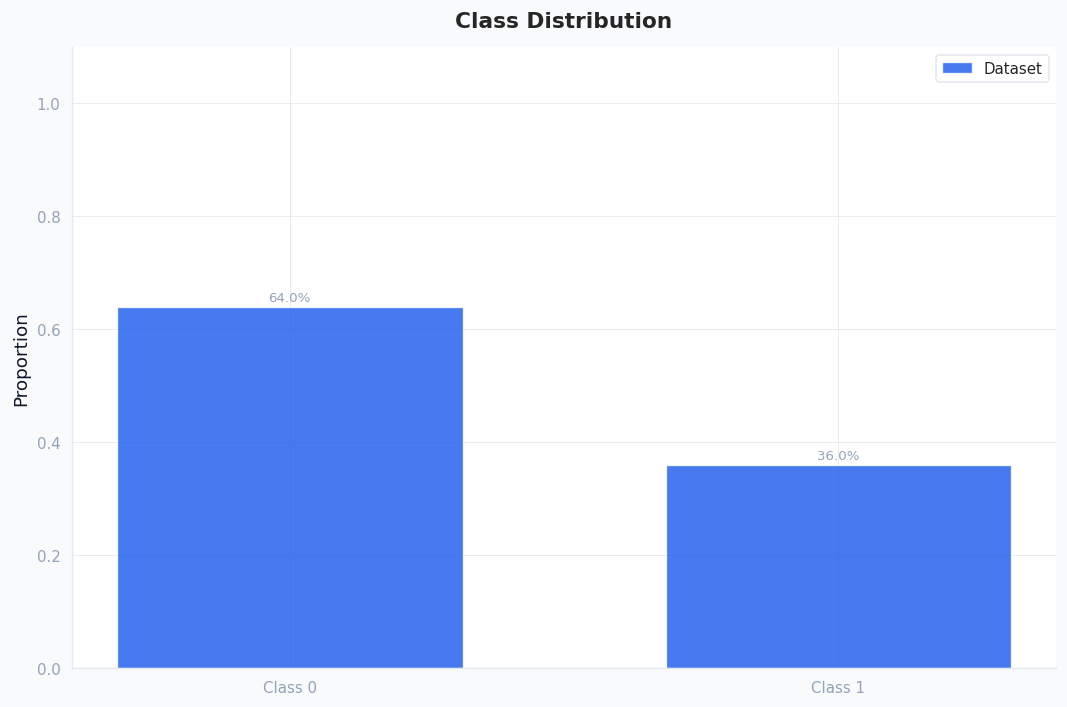

In [6]:
fig, _ = plot_class_distribution(
    {'Dataset': y},
    title='Class Distribution',
)
plt.show()

### Kết quả phân tích Target Distribution

Phân bố của target variable:

| Class | Count | Proportion |
|------|------|------|
| 0 | 1919 | 64.0% |
| 1 | 1081 | 36.0% |

Tỉ lệ giữa majority và minority class:

$$
\text{Class Ratio} =
\frac{1919}{1081} \approx 1.78 : 1
$$

Điều này cho thấy dataset có **class imbalance nhẹ**.

---

### Nhận xét

- **Class 0 chiếm 64%**, đóng vai trò **majority class**
- **Class 1 chiếm 36%**, là **minority class**

Mức imbalance này **không quá nghiêm trọng**, nhưng vẫn đủ để:

- khiến model có xu hướng **thiên về majority class**
- làm **accuracy đánh giá quá lạc quan**

Ví dụ một model luôn dự đoán:

$$
\hat{y} = 0
$$

vẫn đạt accuracy:

$$
Accuracy \approx 64\%
$$

mặc dù model **không học được gì về class 1**.

---

### Ý nghĩa đối với phân tích bias

Class imbalance là một trong những nguyên nhân phổ biến dẫn đến **bias trong machine learning**.

Trong nhiều dataset thực tế:

- minority class thường đại diện cho **rare events**
- ví dụ: fraud detection, medical diagnosis, system failures

Nếu dữ liệu bị **selection bias** hoặc **survivorship bias**, minority class có thể bị giảm thêm, khiến model học sai cấu trúc thật của dữ liệu.
```

---
## 4. Phân tích Feature Distributions

### Khái niệm: Feature Distribution

**Distribution** (phân phối) của một feature mô tả xác suất feature đó nhận các giá trị khác nhau trong dataset.

Việc phân tích distribution giúp:

- hiểu **hình dạng dữ liệu**
- phát hiện **skewness hoặc outliers**
- kiểm tra các giả định của **statistical models**

Một số thống kê quan trọng:

| Thống kê | Công thức | Ý nghĩa |
|---|---|---|
| Mean (trung bình) | $$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$ | Trung tâm phân phối |
| Standard Deviation | $$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$ | Mức độ phân tán |
| Skewness | $$\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^3}{\sigma^3}$$ | Đo độ lệch của phân phối |
| Kurtosis | $$\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^4}{\sigma^4}-3$$ | Đo độ nặng của đuôi phân phối |

---

### Skewness

**Skewness** cho biết mức độ **bất đối xứng của phân phối**.

- $$\text{Skewness} = 0$$ → phân phối **đối xứng** (gần với normal distribution)

- $$\text{Skewness} > 0$$ → **lệch phải**
  đuôi phân phối kéo dài về phía giá trị lớn

- $$\text{Skewness} < 0$$ → **lệch trái**
  đuôi phân phối kéo dài về phía giá trị nhỏ

Skewed distributions có thể ảnh hưởng đến:

- **linear models**
- **distance-based algorithms**
- các **statistical tests**

Trong nhiều trường hợp cần biến đổi dữ liệu, ví dụ:

$$
x' = \log(x)
$$

để làm phân phối gần **normal distribution** hơn.

---

### Khái niệm: KDE Plot (Kernel Density Estimation)

**Kernel Density Estimation (KDE)** là phương pháp ước lượng **hàm mật độ xác suất (Probability Density Function — PDF)** của một biến liên tục từ dữ liệu rời rạc.

Công thức KDE:

$$
\hat{f}(x) =
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(\frac{x - x_i}{h}\right)
$$

trong đó:

- $K$ là **kernel function** (thường dùng Gaussian kernel)
- $h$ là **bandwidth**, tham số kiểm soát độ mượt của đường cong
- $n$ là số lượng samples

Bandwidth nhỏ → đường cong **nhiễu hơn**
Bandwidth lớn → đường cong **mượt hơn**

---

### Histogram vs KDE

| Phương pháp | Đặc điểm |
|---|---|
| Histogram | phụ thuộc vào **bin size** |
| KDE | tạo **đường mật độ mượt liên tục** |

Do đó KDE thường giúp quan sát **hình dạng phân phối tổng thể** rõ hơn histogram.

In [7]:
print('=== Feature Skewness (top 10) ===')
skewness = X.skew().abs().sort_values(ascending=False)
print(skewness.head(10).round(4))

=== Feature Skewness (top 10) ===
feature_14    0.2773
feature_04    0.1855
feature_19    0.1632
feature_10    0.1274
feature_12    0.1218
feature_11    0.0916
feature_15    0.0796
feature_06    0.0782
feature_17    0.0735
feature_02    0.0734
dtype: float64


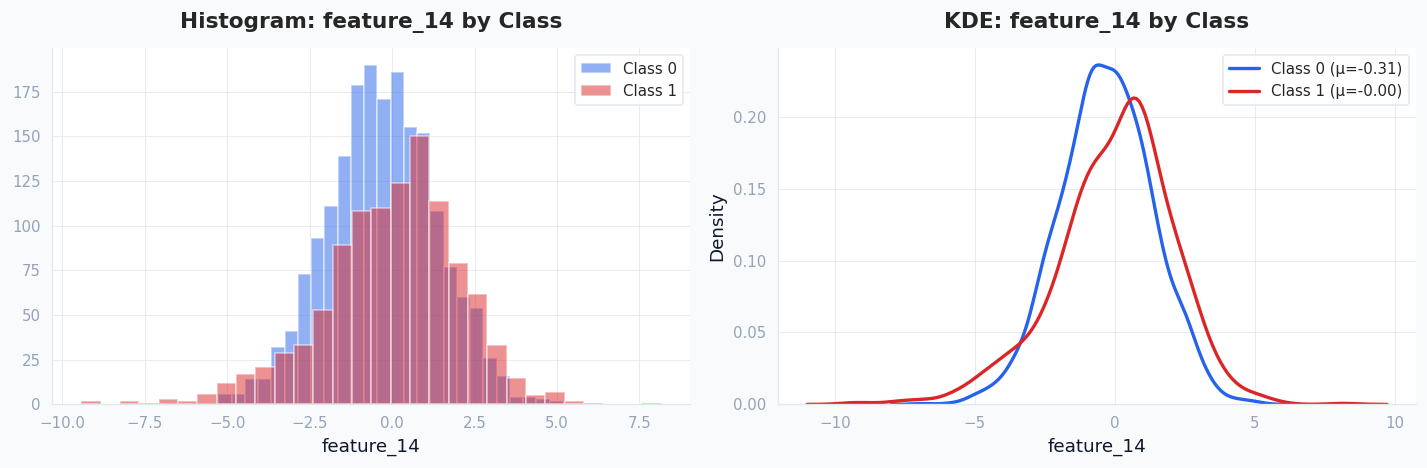

In [8]:
# So sánh distribution của feature_00 theo class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

feature = 'feature_14'

for cls, color in [(0, '#2563EB'), (1, '#DC2626')]:
    subset = X.loc[y == cls, feature]
    axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=f'Class {cls}', edgecolor='white')
    sns.kdeplot(subset, ax=axes[1], color=color, lw=2, label=f'Class {cls} (μ={subset.mean():.2f})')

axes[0].set_title(f'Histogram: {feature} by Class')
axes[0].set_xlabel(feature)
axes[0].legend()

axes[1].set_title(f'KDE: {feature} by Class')
axes[1].set_xlabel(feature)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Histogram và KDE của `feature_14`

Biểu đồ histogram và KDE cho thấy phân phối của `feature_14` theo từng class.

Các quan sát chính:

- Hai class vẫn có **phân phối gần Gaussian**
- Tuy nhiên có **sự dịch chuyển nhẹ giữa hai phân phối**

Mean của hai class:

$$
\mu_{class0} \approx -0.31
$$

$$
\mu_{class1} \approx 0.00
$$

Điều này cho thấy **class 1 có xu hướng nhận giá trị lớn hơn một chút so với class 0**.

---

#### Mức độ phân tách

So với `feature_00`, ta thấy:

- hai đường KDE **không hoàn toàn trùng nhau**
- có **một khoảng dịch chuyển nhỏ giữa hai mean**

Điều này gợi ý rằng `feature_14` có **khả năng phân tách class tốt hơn** so với một số feature khác.

Tuy nhiên:

- hai phân phối vẫn **overlap đáng kể**
- nên **feature đơn lẻ này vẫn chưa đủ để phân loại chính xác**

---

#### Nhận xét

Từ phân tích distribution của `feature_14`:

- phân phối gần **normal**
- có **skewness nhẹ** (≈ 0.28)
- xuất hiện **shift nhỏ giữa hai class**

Những feature có **mean shift giữa các class** thường chứa **signal phân loại**, đặc biệt khi được kết hợp với các features khác trong mô hình.

---
## 5. Feature Correlation Analysis

### Khái niệm: Pearson Correlation

**Pearson correlation coefficient** đo mức độ **tương quan tuyến tính** giữa hai biến ngẫu nhiên.

Công thức:

$$
r =
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

Trong đó:

- $x_i, y_i$ là các quan sát
- $\bar{x}, \bar{y}$ là giá trị trung bình
- $r$ là hệ số tương quan

Giá trị của $r$ nằm trong khoảng:

$$
-1 \le r \le 1
$$

Ý nghĩa:

| Giá trị $r$ | Diễn giải |
|---|---|
| $r = +1$ | Tương quan dương hoàn hảo |
| $r = 0$ | Không có tương quan tuyến tính |
| $r = -1$ | Tương quan âm hoàn hảo |

Trong thực tế:

- $|r| < 0.3$ → tương quan yếu
- $0.3 < |r| < 0.7$ → tương quan trung bình
- $|r| > 0.7$ → tương quan mạnh

---

### Tại sao Correlation quan trọng trong Data Exploration?

Correlation giúp ta:

- hiểu **mối quan hệ giữa các features**
- phát hiện **redundant information**
- xác định các **feature có khả năng predictive**

Trong EDA, correlation thường được biểu diễn bằng **correlation matrix** hoặc **heatmap**.

---

### Liên hệ với Bias

Correlation có thể dẫn đến **confirmation bias** trong feature selection.

Ví dụ:

Một data scientist chỉ chọn các features có:

$$
|r| > 0.5
$$

với target.

Trong trường hợp đó:

- các features có **correlation âm mạnh** có thể bị bỏ qua
- dù chúng vẫn chứa **predictive signal**

Điều này khiến model chỉ học **một phần của cấu trúc dữ liệu**.

---

### Khái niệm: Multicollinearity

**Multicollinearity** xảy ra khi **hai hoặc nhiều features có tương quan mạnh với nhau**, thay vì với target.

Ví dụ:

$$
x_2 \approx a x_1 + b
$$

Điều này nghĩa là hai feature chứa **gần như cùng một thông tin**.

---

### Hệ quả của Multicollinearity

Multicollinearity có thể gây ra nhiều vấn đề trong mô hình thống kê:

- **Coefficients của linear model trở nên không ổn định**
- **Variance của estimator tăng**
- **Feature importance khó diễn giải**

Trong một số trường hợp, hai features gần như tương đương về thông tin, và việc chọn feature nào có thể mang tính **chủ quan**.

---

### Liên hệ với Bias

Multicollinearity có thể làm tăng nguy cơ **confirmation bias**.

Khi nhiều features tương quan cao với nhau, data scientist có thể:

- chọn feature có **correlation đẹp hơn**
- hoặc feature phù hợp với **giả thuyết ban đầu**

Trong khi thực tế các features đó **mang thông tin gần giống nhau**.

In [9]:
print('=== Feature-Target Correlation (Pearson r) ===')
corr_with_target = X.corrwith(y).sort_values(key=abs, ascending=False)
print(corr_with_target.round(4))

=== Feature-Target Correlation (Pearson r) ===
feature_04   -0.2533
feature_02   -0.2391
feature_11   -0.2388
feature_19    0.2313
feature_03   -0.2272
feature_05    0.1648
feature_14    0.0811
feature_12   -0.0655
feature_09    0.0406
feature_07   -0.0202
feature_01    0.0196
feature_10    0.0163
feature_16    0.0160
feature_15   -0.0134
feature_13   -0.0126
feature_08    0.0122
feature_17   -0.0104
feature_18   -0.0051
feature_06    0.0051
feature_00   -0.0024
dtype: float64


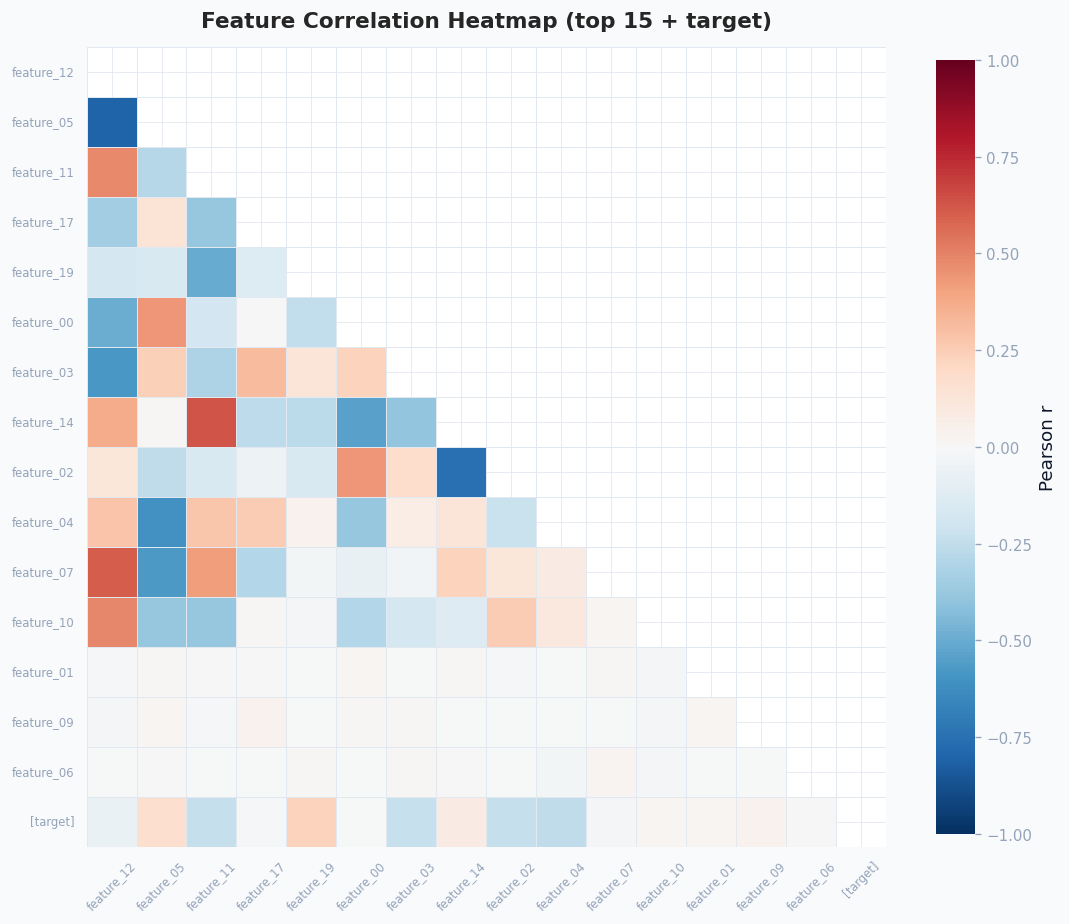

In [10]:
fig, _ = plot_correlation_heatmap(
    X, y=y,
    top_n_features=15,
    title='Feature Correlation Heatmap (top 15 + target)',
)
plt.show()

### Correlation Heatmap Analysis

Biểu đồ **correlation heatmap** cho thấy mức độ tương quan Pearson giữa các features và target.

Màu sắc biểu thị:

- **Đỏ / cam** → tương quan dương
- **Xanh** → tương quan âm
- **Màu tối gần 0** → gần như không có tương quan

Giá trị correlation nằm trong khoảng:

$$
-1 \le r \le 1
$$

---

### Feature–Target Correlation

Quan sát hàng `[target]` trong heatmap cho thấy một số features có tương quan đáng chú ý với target.

Các feature có **|r| cao nhất**:

| Feature | Correlation |
|---|---|
| feature_04 | -0.253 |
| feature_02 | -0.239 |
| feature_11 | -0.239 |
| feature_19 | 0.231 |
| feature_03 | -0.227 |

Các features này có:

$$
|r| \approx 0.23 - 0.25
$$

→ cho thấy **mối quan hệ tuyến tính yếu đến trung bình với target**.

---

### Feature–Feature Correlation

Ngoài tương quan với target, heatmap cũng cho thấy **một số cặp features có tương quan với nhau**.

Điều này có thể xảy ra vì:

- dataset chứa **redundant features**
- một số feature là **linear combination của feature khác**

Hiện tượng này được gọi là **multicollinearity**.

---

### Ý nghĩa đối với mô hình

Correlation analysis giúp:

- xác định **feature có tín hiệu dự đoán**
- phát hiện **redundant features**
- hiểu cấu trúc dữ liệu trước khi train model

Tuy nhiên cần lưu ý:

- Pearson correlation chỉ đo **quan hệ tuyến tính**
- một feature có thể vẫn hữu ích nếu có **quan hệ phi tuyến với target**

---

### Liên hệ với Bias

Nếu quá trình feature selection chỉ dựa trên correlation với target, data scientist có thể vô tình tạo ra **confirmation bias**.

Ví dụ:

chỉ chọn features với

$$
r > 0.2
$$

khi đó các features có **correlation âm mạnh** (nhưng vẫn predictive) có thể bị loại bỏ.

Điều này khiến model học **một phần không đầy đủ của cấu trúc dữ liệu**.
```

---
## 6. Preprocessing Pipeline

### Khái niệm: Train/Test Split

Trong machine learning, dataset thường được chia thành hai phần:

- **Train set**: dùng để huấn luyện model  
- **Test set**: dùng để đánh giá hiệu năng của model trên dữ liệu **chưa từng được thấy**

Giả sử dataset có $n$ samples, ta chia thành:

$$
n = n_{train} + n_{test}
$$

Ví dụ phổ biến:

- Train: **80%**
- Test: **20%**

Nguyên tắc quan trọng nhất:

> **Test set phải hoàn toàn độc lập với quá trình train.**

Nếu thông tin từ test set **vô tình rò rỉ vào quá trình train**, hiện tượng đó gọi là:

**Data Leakage**

Data leakage khiến model có vẻ hoạt động rất tốt trong evaluation nhưng **thất bại khi triển khai thực tế**.

Đây cũng là một dạng **overconfidence bias** trong quá trình xây dựng mô hình.

---

### Khái niệm: Stratified Split

**Stratified split** đảm bảo rằng **phân bố class trong train và test giống với phân bố trong dataset gốc**.

Giả sử dataset có phân bố:

| Class | Proportion |
|---|---|
| 0 | 70% |
| 1 | 30% |

Nếu **không stratify**, có thể xảy ra:

| Dataset | Class 0 | Class 1 |
|---|---|---|
| Train | 65% | 35% |
| Test | 80% | 20% |

Điều này làm **test set không đại diện cho phân bố thật của dữ liệu**.

Với **stratified split**:

| Dataset | Class 0 | Class 1 |
|---|---|---|
| Train | 70% | 30% |
| Test | 70% | 30% |

Điều này đặc biệt quan trọng với **imbalanced datasets**.

Nếu không stratify, evaluation có thể **đánh giá sai hiệu năng model**, dẫn đến một dạng **confirmation bias** trong quá trình phân tích.

---

### Khái niệm: Feature Scaling

Nhiều thuật toán machine learning yêu cầu các features có **scale tương tự nhau**.

Một phương pháp phổ biến là **Standardization** bằng `StandardScaler`.

Công thức:

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

trong đó:

- $\mu$ là **mean của feature**
- $\sigma$ là **standard deviation**

Sau khi scale:

$$
\mu \approx 0, \quad \sigma \approx 1
$$

---

### Tại sao cần Feature Scaling?

Feature scaling quan trọng đối với các mô hình dựa trên **gradient hoặc khoảng cách**.

Ví dụ:

| Model | Có cần scaling không? | Lý do |
|---|---|---|
| Logistic Regression | Có | Gradient descent nhạy với scale |
| SVM | Có | Hyperplane phụ thuộc khoảng cách |
| KNN | Có | Distance-based |
| Neural Networks | Có | Gradient ổn định hơn |
| Random Forest | Không | Chỉ dựa vào threshold split |
| Gradient Boosting | Không | Tree-based |

---

### Leakage Warning

Một lỗi preprocessing phổ biến là **fit scaler trên toàn bộ dataset trước khi split**.

Ví dụ sai:

```python
scaler.fit(X)
X_scaled = scaler.transform(X)
train_test_split(X_scaled, y)
```

Cách đúng:

```python
X_train, X_test, y_train, y_test = train_test_split(...)
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
```

Quy trình đúng đảm bảo:

- **Test set không ảnh hưởng đến train**
- evaluation phản ánh **hiệu năng thực sự của model**

Nếu scaler được fit trên toàn bộ dữ liệu, thông tin từ test set sẽ **rò rỉ vào quá trình training**, dẫn đến **data leakage**.

### Hiểu rõ hơn về Data Leakage

**Data leakage** xảy ra khi thông tin từ **test set hoặc tương lai** vô tình được sử dụng trong quá trình training.

Khi điều này xảy ra, model sẽ học từ dữ liệu mà **trong thực tế nó không thể biết trước**, dẫn đến kết quả evaluation **quá lạc quan**.

---

### Ví dụ phổ biến: Leakage từ Feature Scaling

Giả sử ta chuẩn hóa feature bằng:

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

Trong đó:

- $\mu$ là mean của feature
- $\sigma$ là standard deviation

Nếu ta tính $\mu$ và $\sigma$ từ **toàn bộ dataset**, thì thống kê đó đã bao gồm **test set**.

$$
\mu = \frac{1}{n_{train} + n_{test}} \sum x_i
$$

Điều này có nghĩa là:

> thông tin từ **test set đã ảnh hưởng đến train set**.

Model lúc này được huấn luyện trên dữ liệu đã "biết trước" một phần của test distribution.

---

### Tại sao điều này nguy hiểm?

Giả sử dataset thực tế có **distribution shift** giữa train và test.

Nếu scaler được fit trên toàn bộ data:

- train set sẽ bị **dịch chuyển gần test distribution hơn**
- model sẽ hoạt động **tốt bất thường trong evaluation**

Nhưng khi deploy vào production:

- distribution thật **khác với train**
- performance **giảm mạnh**

---

### Leakage không chỉ xảy ra ở Scaling

Một số bước preprocessing dễ gây leakage:

| Bước xử lý | Nguy cơ |
|---|---|
| Feature scaling | Fit trên toàn bộ data |
| Feature selection | Chọn feature dựa trên toàn bộ dataset |
| PCA | Fit PCA trước khi split |
| Imputation | Tính mean/median từ toàn bộ data |
| Target encoding | Dùng target của test |

Nguyên tắc chung:

> **Mọi bước học thống kê từ dữ liệu phải chỉ dùng train set.**

---

### Quy tắc Pipeline an toàn

Pipeline chuẩn:

1. Split dataset
2. Fit preprocessing **chỉ trên train**
3. Apply transform cho cả train và test
4. Train model trên train
5. Evaluate trên test

Biểu diễn:

$$
\text{Split} \rightarrow \text{Fit(train)} \rightarrow \text{Transform(train,test)}
$$

Cách làm này đảm bảo rằng **test set vẫn là dữ liệu hoàn toàn chưa từng được thấy bởi model**.

In [12]:
tt = preprocess(
    bundle,
    test_size=0.2,
    stratify=True,
    scale_numeric=True,
    random_state=RANDOM_STATE,
)

print(tt)
print(f'\nTrain size : {len(tt.X_train)}')
print(f'Test size  : {len(tt.X_test)}')
print(f'Features   : {len(tt.feature_names)}')

TrainTestBundle(train=2400, test=600, features=20)

Train size : 2400
Test size  : 600
Features   : 20


In [13]:
print('=== Class Distribution After Split ===')
print('Train:')
print(tt.y_train.value_counts(normalize=True).round(3))
print('\nTest:')
print(tt.y_test.value_counts(normalize=True).round(3))

=== Class Distribution After Split ===
Train:
target
0    0.64
1    0.36
Name: proportion, dtype: float64

Test:
target
0    0.64
1    0.36
Name: proportion, dtype: float64


### Kết quả Train/Test Split

Sau khi thực hiện **train/test split**, dataset được chia thành:

| Dataset | Samples | Features |
|---|---|---|
| Train | 2400 | 20 |
| Test | 600 | 20 |

Tương đương với tỉ lệ:

$$
\text{Train} = 80\%, \quad \text{Test} = 20\%
$$

---

### Class Distribution After Split

Phân bố class trong train và test:

| Dataset | Class 0 | Class 1 |
|---|---|---|
| Train | 64% | 36% |
| Test | 64% | 36% |

Ta thấy rằng:

$$
P_{train}(y) \approx P_{test}(y)
$$

Điều này xác nhận rằng **stratified split đã hoạt động đúng**.

---

### Ý nghĩa

Việc giữ nguyên phân bố class giữa train và test giúp:

- đảm bảo **test set đại diện cho dữ liệu thật**
- tránh **evaluation bias**
- giúp metric phản ánh **hiệu năng thực của model**

Nếu không sử dụng stratified split, test set có thể có phân bố khác với train, ví dụ:

| Dataset | Class 0 | Class 1 |
|---|---|---|
| Train | 70% | 30% |
| Test | 85% | 15% |

Trong trường hợp đó, model có thể đạt **accuracy cao một cách giả tạo** vì test set trở nên dễ dự đoán hơn.

---

### Kết luận

Kết quả cho thấy:

- Dataset được chia đúng **80/20**
- **Class distribution được giữ nguyên**
- Test set vẫn là **mẫu đại diện hợp lý cho dữ liệu gốc**

Điều này đảm bảo bước tiếp theo (training và evaluation) **không bị bias do sai lệch phân bố dữ liệu**.

---
## 7. Informative vs Noise Features

### Khái niệm: F-statistic và Feature Relevance

Trong **feature selection**, một cách phổ biến để đo mức độ một feature có khả năng phân biệt giữa các class là sử dụng **ANOVA F-statistic**.

F-statistic đo tỉ lệ giữa:

- **Between-group variance** — độ khác biệt giữa các class
- **Within-group variance** — độ biến thiên bên trong từng class

Công thức:

$$
F =
\frac{\text{Between-group variance}}{\text{Within-group variance}}
=
\frac{
\sum_{k=1}^{K} n_k(\bar{x}_k - \bar{x})^2 / (K-1)
}{
\sum_{k=1}^{K} \sum_{i=1}^{n_k} (x_{ki} - \bar{x}_k)^2 / (N-K)
}
$$

Trong đó:

- $K$ là số classes
- $n_k$ là số mẫu trong class $k$
- $\bar{x}_k$ là mean của feature trong class $k$
- $\bar{x}$ là mean của feature trên toàn bộ dataset
- $N$ là tổng số samples

---

### Diễn giải F-statistic

| Giá trị F | Ý nghĩa |
|---|---|
| F cao | Feature có **khả năng phân biệt class tốt** |
| F thấp | Feature **không giúp phân loại nhiều** |

Trực giác:

Nếu **mean của feature khác nhau rõ rệt giữa các class**, thì:

$$
\bar{x}_1 \neq \bar{x}_2
$$

→ **between-class variance lớn** → **F-statistic cao**.

Ngược lại, nếu các class có phân phối gần giống nhau:

$$
\bar{x}_1 \approx \bar{x}_2
$$

→ feature có thể chỉ là **noise**.

---

### p-value và Statistical Significance

Khi tính F-statistic, ta thường đi kèm **p-value** để kiểm tra ý nghĩa thống kê.

| p-value | Diễn giải |
|---|---|
| $p < 0.05$ | Feature có **ý nghĩa thống kê** |
| $p > 0.05$ | Feature có thể **không liên quan đến target** |

Ý nghĩa:

$p$ biểu thị xác suất quan sát được F-statistic lớn như vậy **nếu thực sự không có sự khác biệt giữa các class**.

---

### Informative vs Noise Features

Trong dataset:

- **Informative features** → có F-statistic cao và p-value thấp
- **Noise features** → F-statistic thấp, p-value cao

Do dataset này được sinh bằng **synthetic generator**, một số features được thiết kế sẵn là:

- **informative**
- **redundant**
- **noise**

ANOVA giúp ta **khôi phục lại cấu trúc này từ dữ liệu**.

---

### Liên hệ với Confirmation Bias

Trong thực tế, feature selection dựa trên p-value có thể dẫn đến **confirmation bias**.

Ví dụ:

Một data scientist đặt quy tắc:

$$
p < 0.05
$$

và loại bỏ tất cả feature còn lại.

Tuy nhiên:

- ngưỡng này **tùy ý**
- nhiều feature có thể **hữu ích khi kết hợp với feature khác**
- một số quan hệ **phi tuyến** không được ANOVA phát hiện

Nếu chỉ giữ những feature **phù hợp với giả thuyết ban đầu**, quá trình phân tích có thể trở nên **thiên lệch**.

In [14]:
f_scores, p_values = f_classif(tt.X_train, tt.y_train)

df_scores = pd.DataFrame({
    'feature': tt.feature_names,
    'f_score': f_scores,
    'p_value': p_values,
    'significant': p_values < 0.05,
}).sort_values('f_score', ascending=False)

print(f'Significant features (p<0.05): {df_scores["significant"].sum()}/{len(df_scores)}')
display(df_scores.head(10).round(4))

Significant features (p<0.05): 9/20


,feature,f_score,p_value,significant
11,numeric__feature_11,154.6293,0.0000,True
4,numeric__feature_04,143.6789,0.0000,True
3,numeric__feature_03,137.7708,0.0000,True
2,numeric__feature_02,137.0021,0.0000,True
19,numeric__feature_19,134.2820,0.0000,True
5,numeric__feature_05,59.1565,0.0000,True
14,numeric__feature_14,13.4743,0.0002,True
12,numeric__feature_12,8.4461,0.0037,True
9,numeric__feature_09,5.4221,0.0200,True
7,numeric__feature_07,2.9390,0.0866,False


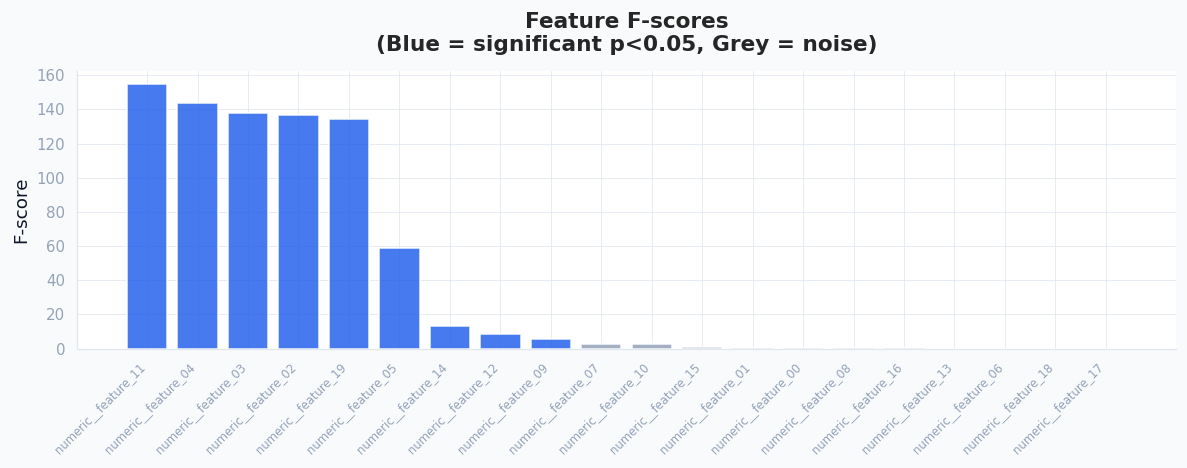

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2563EB' if s else '#94A3B8' for s in df_scores['significant']]
ax.bar(range(len(df_scores)), df_scores['f_score'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(df_scores)))
ax.set_xticklabels(df_scores['feature'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('F-score')
ax.set_title('Feature F-scores\n(Blue = significant p<0.05, Grey = noise)')
plt.tight_layout()
plt.show()

### Kết quả ANOVA Feature Selection

Kết quả kiểm định **ANOVA F-test** cho thấy:

$$
9/20
$$

features có **ý nghĩa thống kê (p < 0.05)**.

Các features có F-score cao nhất:

| Feature | F-score | p-value | Significant |
|---|---|---|---|
| numeric_feature_11 | 154.63 | <0.001 | True |
| numeric_feature_04 | 143.68 | <0.001 | True |
| numeric_feature_03 | 137.77 | <0.001 | True |
| numeric_feature_02 | 137.00 | <0.001 | True |
| numeric_feature_19 | 134.28 | <0.001 | True |
| numeric_feature_05 | 59.16 | <0.001 | True |
| numeric_feature_14 | 13.47 | <0.001 | True |
| numeric_feature_12 | 8.45 | 0.0037 | True |
| numeric_feature_09 | 5.42 | 0.020 | True |

Các feature này có **between-class variance lớn hơn đáng kể so với within-class variance**, nghĩa là giá trị của chúng **khác biệt rõ rệt giữa hai class**.

---

### Noise Features

Các feature có **p-value > 0.05** được xem là **không có ý nghĩa thống kê** trong ANOVA.

Ví dụ:

| Feature | F-score | p-value |
|---|---|---|
| numeric_feature_07 | 2.94 | 0.086 |
| numeric_feature_10 | ~2 | >0.05 |
| numeric_feature_15 | ~1 | >0.05 |
| numeric_feature_01 | ~1 | >0.05 |

Những feature này có thể:

- chỉ chứa **noise**
- hoặc có **quan hệ phi tuyến với target** mà ANOVA không phát hiện được.

---

### Phân bố F-score

Biểu đồ F-score cho thấy sự **phân tách khá rõ ràng giữa informative features và noise features**.

- **Thanh màu xanh**: feature có $p < 0.05$
- **Thanh màu xám**: feature có $p \ge 0.05$

Ta thấy một nhóm nhỏ features có **F-score rất cao (>100)**, trong khi phần lớn các feature còn lại có **F-score gần 0**.

Điều này phù hợp với cách dataset được tạo ra, trong đó chỉ một số features là **informative**, còn lại là **noise hoặc redundant features**.

---

### Ý nghĩa đối với Feature Selection

Kết quả ANOVA cho thấy:

- khoảng **45% features chứa signal phân loại**
- phần còn lại có **đóng góp rất nhỏ hoặc không đáng kể**

Tuy nhiên, cần lưu ý rằng:

- ANOVA chỉ phát hiện **quan hệ tuyến tính giữa feature và target**
- một số feature có thể **hữu ích khi kết hợp với feature khác**
- các mô hình phi tuyến (Random Forest, Gradient Boosting) vẫn có thể khai thác signal từ các feature có F-score thấp.

---

### Liên hệ với Bias

Nếu quá trình feature selection chỉ dựa trên:

$$
p < 0.05
$$

data scientist có thể vô tình **loại bỏ các feature hữu ích**.

Việc chọn ngưỡng thống kê một cách cứng nhắc có thể dẫn đến:

- **confirmation bias**
- **model underfitting**
- bỏ sót **interaction effects giữa các features**.

---
## 8. Feature Variance Analysis

### Khái niệm: Variance của Feature

**Variance** đo mức độ phân tán của một feature quanh giá trị trung bình.

Công thức:

$$
\text{Var}(X) =
\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

trong đó:

- $x_i$ là giá trị của feature
- $\bar{x}$ là mean của feature
- $n$ là số lượng quan sát

Variance lớn → feature **biến động mạnh**
Variance nhỏ → feature **gần như không thay đổi**

---

### Zero Variance Features

Một feature có **zero variance** khi tất cả giá trị đều giống nhau:

$$
x_1 = x_2 = \dots = x_n
$$

khi đó:

$$
\text{Var}(X) = 0
$$

Feature như vậy **không chứa bất kỳ thông tin phân biệt nào** giữa các samples.

Ví dụ:

| Sample | Feature |
|---|---|
| 1 | 5 |
| 2 | 5 |
| 3 | 5 |

→ feature này nên **loại bỏ trước khi training**.

---

### Low Variance Features

**Low variance features** là những feature có độ biến động rất nhỏ.

Ví dụ:

| Sample | Feature |
|---|---|
| 1 | 0.99 |
| 2 | 1.01 |
| 3 | 1.00 |

Feature gần như **không thay đổi giữa các samples**, nên thường:

- ít giúp phân biệt class
- có ảnh hưởng nhỏ đến model

Do đó nhiều pipeline sử dụng **Variance Threshold** để loại bỏ:

$$
\text{Var}(X) < \tau
$$

trong đó $\tau$ là ngưỡng variance tối thiểu.

---

### Ảnh hưởng của Feature Scaling

Sau khi áp dụng **StandardScaler**:

$$
x_{\text{scaled}} =
\frac{x - \mu}{\sigma}
$$

các features sẽ có:

$$
\mu \approx 0
\quad
\sigma \approx 1
$$

tương đương với:

$$
\text{Var}(X) \approx 1
$$

Vì vậy **variance analysis nên thực hiện trên raw data**, trước khi scaling.

---

### Tại sao Variance Analysis quan trọng?

Variance analysis giúp:

- phát hiện **feature vô dụng**
- giảm **dimension của dataset**
- cải thiện **training speed**
- giảm nguy cơ **overfitting**

Đây thường là **bước filter đầu tiên trong feature selection**.

---

### Liên hệ với Bias

Low variance features thường bị loại bỏ vì trông có vẻ **ít thông tin**.

Tuy nhiên trong một số trường hợp, chúng có thể:

- đại diện cho **rare events**
- chứa **tín hiệu quan trọng nhưng hiếm**

Ví dụ:

- một biến kích hoạt chỉ khi xảy ra **fraud**
- một indicator chỉ xuất hiện khi hệ thống **gặp lỗi**

Nếu loại bỏ các feature này, ta có thể vô tình tạo ra **survivorship bias ở cấp độ feature**, vì dataset chỉ giữ lại các patterns phổ biến.

In [16]:
print('=== Feature Variance (raw X, top & bottom 5) ===')
variances = X.var().sort_values(ascending=False)
print('Highest variance:')
print(variances.head(5).round(4))
print('\nLowest variance:')
print(variances.tail(5).round(4))

=== Feature Variance (raw X, top & bottom 5) ===
Highest variance:
feature_12    9.6712
feature_05    7.1203
feature_11    6.2528
feature_17    4.3773
feature_19    3.6215
dtype: float64

Lowest variance:
feature_13    1.0113
feature_08    1.0048
feature_16    0.9995
feature_15    0.9909
feature_18    0.9785
dtype: float64


### Kết quả Feature Variance Analysis

Variance của các features được tính trên **raw dataset (trước khi scaling)** để đánh giá mức độ biến thiên tự nhiên của từng feature.

---

### Features có Variance cao nhất

| Feature | Variance |
|---|---|
| feature_12 | 9.67 |
| feature_05 | 7.12 |
| feature_11 | 6.25 |
| feature_17 | 4.38 |
| feature_19 | 3.62 |

Những feature này có **mức độ biến động lớn**, nghĩa là giá trị của chúng phân tán rộng quanh mean.

Variance cao có thể cho thấy:

- feature chứa **nhiều thông tin biến thiên**
- có khả năng **phân biệt các samples tốt hơn**

Tuy nhiên, variance cao **không đồng nghĩa với predictive power** — một feature có thể biến động lớn nhưng vẫn không liên quan đến target.

---

### Features có Variance thấp nhất

| Feature | Variance |
|---|---|
| feature_13 | 1.01 |
| feature_08 | 1.00 |
| feature_16 | 1.00 |
| feature_15 | 0.99 |
| feature_18 | 0.98 |

Các feature này có variance gần **1**, cho thấy mức độ biến thiên tương đối nhỏ so với các feature khác.

Tuy nhiên:

$$
\text{Var}(X) > 0
$$

cho tất cả features → **không có zero-variance feature** trong dataset.

---

### Nhận xét

Từ phân tích variance:

- dataset **không chứa feature hoàn toàn vô dụng (variance = 0)**
- variance giữa các features **khác nhau đáng kể**
- một số feature có **variance cao gấp nhiều lần các feature khác**

Điều này cho thấy dữ liệu có **mức độ phân tán không đồng đều giữa các features**, điều thường gặp trong dữ liệu thực tế.

---

### Liên hệ với Feature Selection

Variance analysis thường được dùng như **bước lọc đầu tiên** trong pipeline:

$$
\text{Remove feature if } \text{Var}(X) < \tau
$$

với $\tau$ là ngưỡng variance tối thiểu.

Trong dataset này:

- không feature nào có variance cực thấp
- nên **không cần loại bỏ feature dựa trên variance threshold**.

---
## 9. Pairwise Feature Relationships

### Khái niệm: Scatter Plot Matrix (Pair Plot)

**Pair plot** (scatter plot matrix) trực quan hóa **mối quan hệ giữa từng cặp features** trong dataset, đồng thời phân biệt các điểm theo **class label**.

Trong một pair plot:

- mỗi **ô ngoài đường chéo** là scatter plot giữa hai features
- các điểm thường được **tô màu theo class**
- các ô **trên đường chéo** thường hiển thị distribution của từng feature (histogram hoặc KDE)

Nếu dataset có $p$ features, pair plot hiển thị:

$$
p \times p
$$

biểu đồ nhỏ.

---

### Các Pattern quan trọng cần quan sát

**1. Linear Separation**

Hai class có thể tách nhau gần như theo một đường thẳng.

Ví dụ trực giác:

```
class 0   x x x x
          x x x x
------------------------
class 1            o o o
                   o o o
```

Điều này gợi ý rằng **linear models** có thể hoạt động tốt, ví dụ:

- Logistic Regression
- Linear SVM

---

**2. Non-Linear Boundary**

Classes có thể tách nhau nhưng theo **đường cong hoặc hình phức tạp**.

Ví dụ:

```
class 0  x x x
        x     x
       x       x
        x     x
         x x x

class 1  o o o o o
```

Trong trường hợp này cần các mô hình **phi tuyến**, ví dụ:

- Random Forest
- Gradient Boosting
- Neural Networks

---

**3. Cluster Overlap**

Hai class chồng chéo mạnh:

```
x o x o x
o x o x o
x o x o x
```

Điều này cho thấy:

- features hiện tại **không đủ để phân tách classes**
- accuracy tối đa có thể đạt được **bị giới hạn**

---

### Vai trò trong Exploratory Data Analysis

Pair plot giúp:

- phát hiện **feature interactions**
- nhận diện **clusters tự nhiên**
- quan sát **decision boundary tiềm năng**
- kiểm tra **separation giữa classes**

Đây là một công cụ trực quan quan trọng trước khi train model.

---

### Liên hệ với Bias

Quan sát pair plot cũng giúp phát hiện **confirmation bias** tiềm ẩn.

Nếu một vài features cho thấy **separation rất rõ ràng**, data scientist có thể:

- chỉ tập trung vào các feature đó
- bỏ qua các feature có pattern **phức tạp hơn**

Điều này có thể khiến model:

- học **pattern đơn giản nhưng không đầy đủ**
- bỏ lỡ **interactions quan trọng giữa các features**.

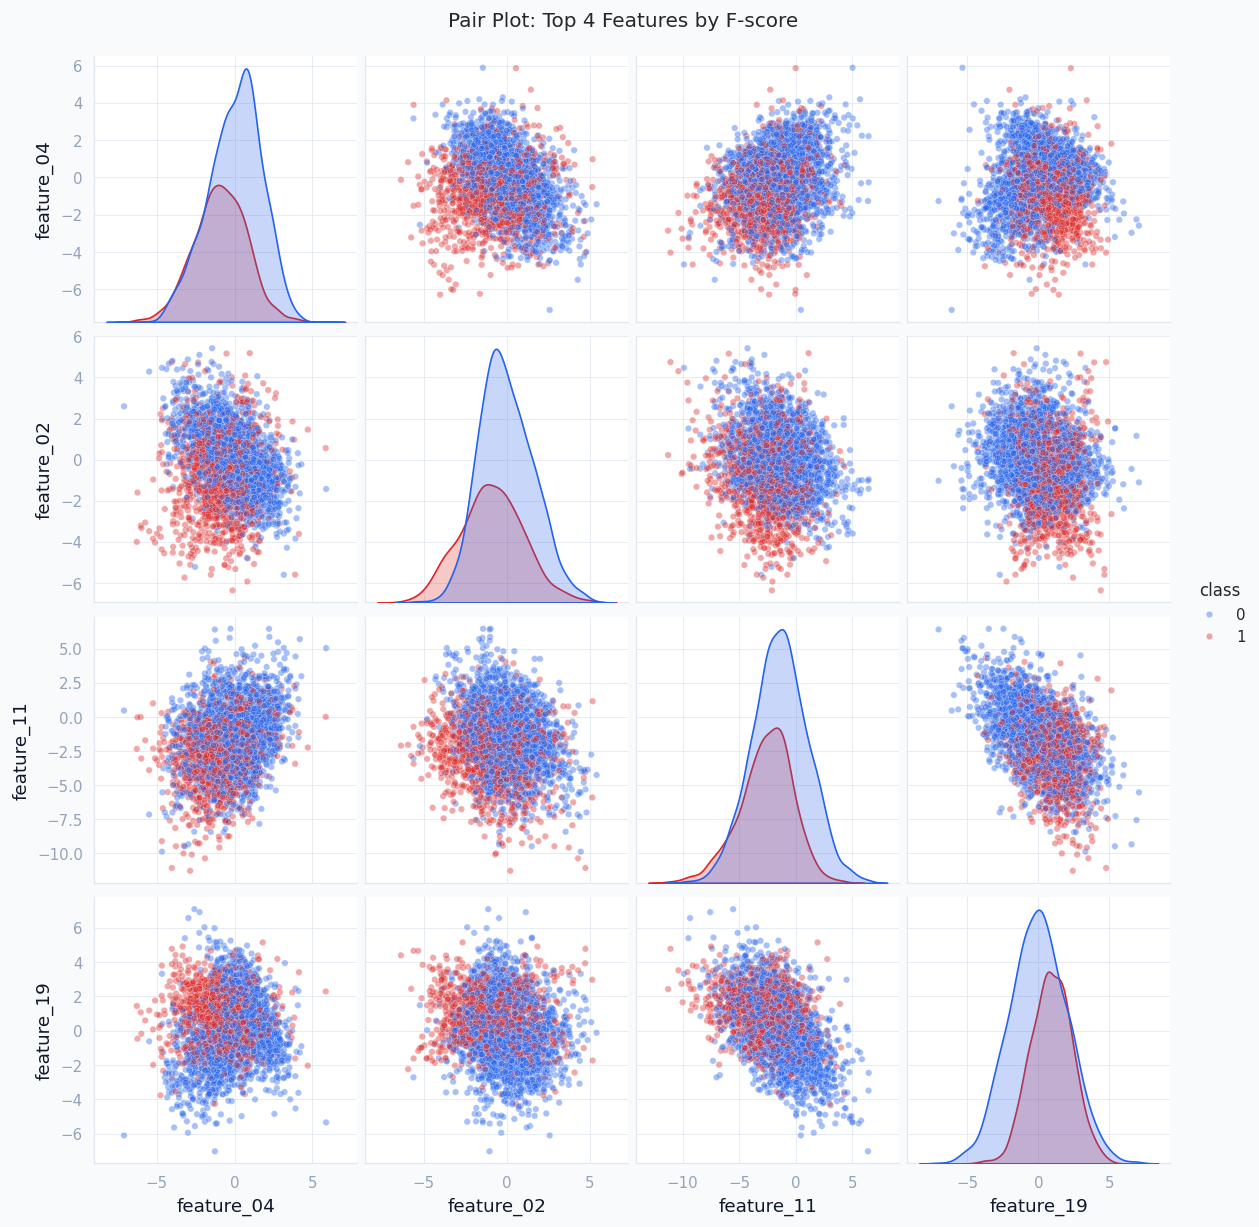

In [17]:
f_raw, _ = f_classif(X, y)
top4 = X.columns[f_raw.argsort()[::-1][:4]].tolist()

df_plot = X[top4].copy()
df_plot['class'] = y.values

g = sns.pairplot(
    df_plot,
    hue='class',
    palette={0: '#2563EB', 1: '#DC2626'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
)
g.fig.suptitle('Pair Plot: Top 4 Features by F-score', y=1.02)
plt.show()

### Phân tích Pair Plot (Top 4 Features theo F-score)

Pair plot hiển thị mối quan hệ giữa 4 features có **F-score cao nhất**:

- `feature_11`
- `feature_04`
- `feature_02`
- `feature_19`

Các điểm được tô màu theo class:

- **Xanh** → class 0
- **Đỏ** → class 1

---

### Distribution trên từng Feature (đường chéo)

Các KDE plot trên đường chéo cho thấy:

- phân phối của hai class **khác nhau rõ rệt**
- mean của hai class **dịch chuyển đáng kể**

Ví dụ:

- `feature_11` có sự dịch chuyển rõ giữa hai class
- `feature_19` cũng cho thấy **mean shift đáng kể**

Điều này phù hợp với kết quả **F-test**, nơi các feature này có F-score rất cao.

---

### Quan hệ giữa các Feature

Các scatter plot ngoài đường chéo cho thấy:

- tồn tại **tương quan nhẹ giữa một số feature**
- các điểm tạo thành **elliptical clusters**

Điều này cho thấy features có thể chứa **redundant information** hoặc **linear relationships**.

---

### Mức độ phân tách Class

Dù các feature có signal rõ:

- hai class vẫn **overlap đáng kể**
- không tồn tại **linear boundary hoàn hảo**

Điều này cho thấy bài toán **không trivially separable**.

---

### Hàm ý cho mô hình

Từ pair plot có thể suy ra:

- Logistic Regression có thể học được **một phần signal**
- Nhưng các mô hình **phi tuyến** có thể tận dụng **interaction giữa features** tốt hơn

Ví dụ:

- Random Forest
- Gradient Boosting
- Neural Networks

---

### Liên hệ với Bias

Nếu chỉ nhìn vào pair plot, data scientist có thể:

- chỉ chọn các feature có **separation rõ ràng**
- bỏ qua các feature có pattern phức tạp hơn

Điều này có thể dẫn đến **confirmation bias trong feature selection**.

---
## 10. Summary

### Những gì đã khám phá trong notebook này:

| Bước | Kỹ thuật | Khái niệm chính |
|---|---|---|
| Load data | `load_dataset()` | Synthetic data, class imbalance |
| Shape & types | `.describe()`, `.dtypes` | Feature matrix, missing values |
| Target analysis | `value_counts()` | Class distribution, imbalance ratio |
| Feature dist | Histogram, KDE | Skewness, kurtosis, PDF |
| Correlation | `corrwith()`, heatmap | Pearson r, multicollinearity |
| Preprocessing | `preprocess()` | Train/test split, stratify, StandardScaler |
| Feature relevance | F-statistic, p-value | ANOVA, statistical significance |
| Variance | `.var()` | Zero variance, low variance |
| Pairwise | Pair plot | Separability, class overlap |

### Chuẩn bị cho notebook tiếp theo:

Notebook 02 sẽ dùng chính dataset này để **inject bias có kiểm soát** và quan sát tác động. Các khái niệm về distribution, correlation và class imbalance ở đây sẽ là baseline để so sánh sau khi bias được áp dụng.

In [18]:
print('=== Dataset Summary ===')
print(f'Total samples     : {len(X)}')
print(f'Features          : {X.shape[1]}')
print(f'Class 0 (majority): {(y==0).sum()} ({(y==0).mean():.1%})')
print(f'Class 1 (minority): {(y==1).sum()} ({(y==1).mean():.1%})')
print(f'Imbalance ratio   : {(y==0).sum()/(y==1).sum():.2f}:1')
print(f'Significant feats : {df_scores["significant"].sum()}/{len(df_scores)}')
print(f'Train size        : {len(tt.X_train)}')
print(f'Test size         : {len(tt.X_test)}')

=== Dataset Summary ===
Total samples     : 3000
Features          : 20
Class 0 (majority): 1919 (64.0%)
Class 1 (minority): 1081 (36.0%)
Imbalance ratio   : 1.78:1
Significant feats : 9/20
Train size        : 2400
Test size         : 600
